In [1]:
import pandas as pd
import numpy as np
import os
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.table import Table

import seaborn as sns
import statsmodels.api as sm

import ast
# for IRT
import pymc as pm
import arviz as az

sns.set_theme(style="whitegrid")

# Synthetic Assessment Data Pipeline (SAD-Pipe) - Analysis

## Visual Encoding Reference
- This section defines all color palettes and colormaps used throughout the analysis.
- Centralizing the visual encodings ensures stylistic consistency and accessibility

All palettes have been checked for common forms of color vision deficiency.

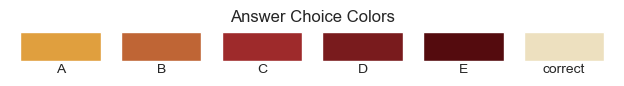

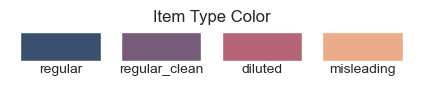

In [2]:
#change the colors to your taste, these have been checked for Protanopia, Deuteranopia, Tritanopia, Achromatopsia
def plot_color_swatch(color_dict, title):
    """
    Plots a horizontal row of labeled color swatches.
    color_dict: {'label': '#hex'}
    """
    labels = list(color_dict.keys())
    colors = list(color_dict.values())

    fig, ax = plt.subplots(figsize=(len(labels)*1.3, 0.4))

    for i, (label, color) in enumerate(color_dict.items()):
        ax.bar(i, 1, color=color)
        ax.text(i, -0.1, label, ha='center', va='top', fontsize=10)

    ax.set_title(title, fontsize=12)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_xlim(-0.5, len(labels)-0.5)
    ax.set_frame_on(False)
    plt.show()


def plot_cmap(cmap, title):
    gradient = np.linspace(0, 1, 256).reshape(1, -1)

    fig, ax = plt.subplots(figsize=(6, 0.4))
    ax.imshow(gradient, aspect='auto', cmap=cmap)
    ax.set_title(title, fontsize=12)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_frame_on(False)
    plt.show()

# --- Answer choice colors (A–E + correct) ---
def get_colors(correct_answer):
    base_colors = {
        'A':'#e09f3e',
        'B':'#bf6535',
        'C':'#9E2A2B',
        'D':'#791B1D',
        'E':'#540b0e',
        'correct':'#ede0bf'
    }
    # Force correct answer to be the same color
    base_colors[correct_answer] = '#ede0bf'
    return base_colors
colors = get_colors(correct_answer='correct')  # or any letter
plot_color_swatch(colors, "Answer Choice Colors")

# --- Item type colors ---
item_type_colors = {
    'regular':       '#3B5070',
    'regular_clean': '#765B7A',
    'diluted':       '#B56576',
    'misleading':    '#eaac8b'  

}
plot_color_swatch(item_type_colors, "Item Type Color")

def make_color_dict(prefix, labels, palette="Blues_d"):
    colors = sns.color_palette(palette, len(labels)).as_hex()
    return {label: color for label, color in zip(labels, colors)}



## Load Data
Load the simulated dataset (answer matrix, scored responses, item metadata, and person metadata).

PKL files are used for fast loading; CSV versions are available if preferred.


In [3]:
# as pkl, use read_csv and .csv, instead of .pkl if preferred
DATA_DIR_CANDIDATES = [
    Path("../data/simulation_results"),
    Path("../data"),
    Path("data"),
]

DATA_DIR = None
for d in DATA_DIR_CANDIDATES:
    if (d / "answer_matrix.pkl").exists():
        DATA_DIR = d
        break

if DATA_DIR is None:
    raise FileNotFoundError(
        "Could not find simulation output files. Expected one of these folders to contain answer_matrix.pkl: "
        + ", ".join(str(p) for p in DATA_DIR_CANDIDATES)
        + ". Run the simulation notebook first, or adjust DATA_DIR_CANDIDATES."
    )

answer_matrix = pd.read_pickle(DATA_DIR / "answer_matrix.pkl")
scored_responses = pd.read_pickle(DATA_DIR / "scored_responses.pkl")
testtakers_post_analysis = pd.read_pickle(DATA_DIR / "testtakers.pkl")
item_analysis = pd.read_pickle(DATA_DIR / "item_metadata.pkl")

print(f"Loaded simulation data from: {DATA_DIR.resolve()}")

ANALYSIS_DIR = DATA_DIR.parent / "analysis_results"
ANALYSIS_DIR.mkdir(parents=True, exist_ok=True)

BASE_DIR = ANALYSIS_DIR / "item_plots"
BASE_DIR.mkdir(parents=True, exist_ok=True)



In [4]:
# prepare the data for CTT and IRT
def make_binary_matrix(answer_matrix, item_analysis):
    """
    Converts the categorical answer matrix into a binary correctness matrix.
    Each cell is 1 if the examinee selected the correct option, 0 otherwise.
    """

    answer_key = dict(zip(item_analysis["item"], item_analysis["correct_answer"]))
    items = list(answer_key.keys())

    binary = pd.DataFrame({
        item: (answer_matrix[item] == answer_key[item]).astype(int)
        for item in items
    })

    return binary

binary = make_binary_matrix(answer_matrix, item_analysis)

In [5]:
item_analysis

,item,item_type,num_options,correct_answer,a_param,b_param,slip,distractors,distractor_weights
0,item1,regular_clean,4,A,1.003326,0.889566,0.019005,"[B, C, D]","{'B': 0.45, 'C': 0.3, 'D': 0.25000000000000006}"
1,item2,regular_clean,5,D,1.448345,-0.810366,0.004695,"[A, B, C, E]","{'A': 0.45, 'B': 0.3, 'C': 0.12500000000000003..."
2,item3,regular_clean,5,D,1.651941,-0.140658,0.021120,"[A, B, C, E]","{'A': 0.45, 'B': 0.3, 'C': 0.12500000000000003..."
3,item4,regular,5,A,0.937108,1.549212,0.107733,"[B, C, D, E]","{'B': 0.45, 'C': 0.3, 'D': 0.12500000000000003..."
4,item5,misleading,4,D,0.892433,0.376604,0.083355,"[A, B, C]","{'A': 0.65625, 'B': 0.18749999999999997, 'C': ..."
...,...,...,...,...,...,...,...,...,...
75,item76,regular,5,C,1.099112,-2.431094,0.072278,"[A, B, D, E]","{'A': 0.5217391304347826, 'B': 0.2608695652173..."
76,item77,regular,4,A,0.833079,-2.226736,0.005027,"[B, C, D]","{'B': 0.45, 'C': 0.3, 'D': 0.25000000000000006}"
77,item78,regular,3,C,1.616659,-1.373761,0.020109,"[A, B]","{'A': 0.6, 'B': 0.4}"
78,item79,diluted,4,C,0.603983,-0.732294,0.051830,"[A, B, D]","{'A': 0.34615384615384615, 'B': 0.461538461538..."


## Classical Test Theory (CTT) Diagnostics
This section computes core CTT statistics to evaluate item functioning:
- item difficulty (p-value)
- item discrimination (item–total correlation, corrected)
- internal consistency (Cronbach’s alpha)

These diagnostics provide a first check of item quality and help verify
that the simulated response patterns align with the intended psychometric structure.



In [6]:
# The Functions

def classical_item_analysis(binary):
    """
    Computes item difficulty and corrected item–total correlations.
    
    Parameters
    ----------
    binary : DataFrame
        Matrix of 0/1 correctness (rows = persons, columns = items)
    
    Returns
    -------
    DataFrame with columns:
        - item
        - difficulty (p-value)
        - discrimination (corrected item–total correlation)
    """

    items = binary.columns.tolist()
    total_score = binary.sum(axis=1)

    results = []
    for item in items:
        p_value = binary[item].mean()
        total_score_excl = total_score - binary[item]
        corr = np.corrcoef(binary[item], total_score_excl)[0, 1]

        results.append({
            "item": item,
            "difficulty": round(p_value, 3),
            "discrimination": round(corr, 3)
        })

    return pd.DataFrame(results)


def cronbach_alpha(binary):
    """
    Computes Cronbach's alpha for internal consistency.
    """
    k = binary.shape[1]
    item_vars = binary.var(axis=0, ddof=1)
    total_var = binary.sum(axis=1).var(ddof=1)
    alpha = (k/(k-1)) * (1 - item_vars.sum()/total_var)
    return round(alpha, 3)


In [7]:
# --- Run CTT Analysis ---
ctt_results = classical_item_analysis(binary)
alpha = cronbach_alpha(binary)

ctt_results.head()

,item,difficulty,discrimination
0,item1,0.325,0.168
1,item2,0.725,0.374
2,item3,0.545,0.353
3,item4,0.315,0.163
4,item5,0.410,0.310


In [8]:
# --- Merge CTT results with item metadata ---
item_analysis_ctt = item_analysis.merge(
    ctt_results,
    on="item",
    how="left"
)


Cronbach's alpha: 0.834

Difficulty summary:
count    80.000000
mean      0.643687
std       0.171079
min       0.275000
25%       0.543750
50%       0.630000
75%       0.776250
max       0.970000
Name: difficulty, dtype: float64 

Discrimination (item–total correlation) summary:
count    80.000000
mean      0.217463
std       0.101586
min      -0.030000
25%       0.154000
50%       0.234000
75%       0.287750
max       0.459000
Name: discrimination, dtype: float64 



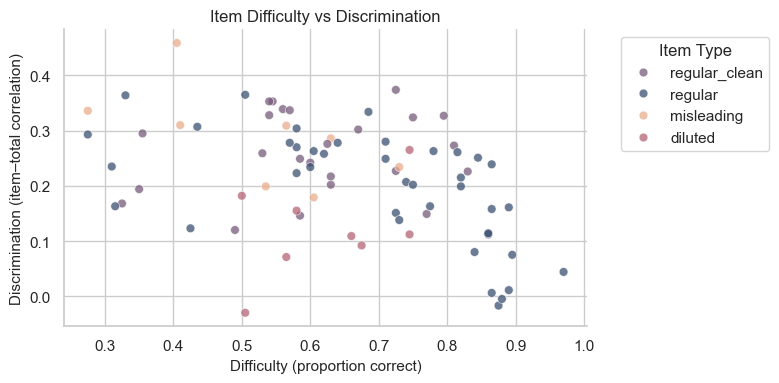

In [9]:
print(f"Cronbach's alpha: {alpha}\n")

print("Difficulty summary:")
print(item_analysis_ctt["difficulty"].describe(), "\n")

print("Discrimination (item–total correlation) summary:")
print(item_analysis_ctt["discrimination"].describe(), "\n")


# --- Difficulty vs Discrimination (CTT) ---
plt.figure(figsize=(8, 4))
ax = sns.scatterplot(
    data=item_analysis_ctt,
    x="difficulty",
    y="discrimination",
    s=40,
    alpha=0.75,
    hue="item_type",
    palette=item_type_colors,
)

# Titles and labels
ax.set_title("Item Difficulty vs Discrimination", fontsize=12)
ax.set_xlabel("Difficulty (proportion correct)", fontsize=11)
ax.set_ylabel("Discrimination (item–total correlation)", fontsize=11)

# Place legend outside the plot
ax.legend(title="Item Type", bbox_to_anchor=(1.05, 1), loc='upper left')

# Hide top and right spines
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

## Bayesian 2PL IRT model
This section fits a Bayesian 2‑Parameter Logistic (2PL) IRT model to the binary response matrix.
The model estimates:

- **θₚ**: latent ability for each person  
- **aᵢ**: item discrimination (slope of the ICC)  
- **bᵢ**: item difficulty (location on the ability scale)

### Priors
- **aᵢ ~ LogNormal(0, 0.5)** ensures strictly positive discrimination  
- **bᵢ ~ Normal(0, 2)** provides a weakly informative location prior  
- **θₚ ~ Normal(0, 1)** follows the standard IRT identification convention

### Likelihood
For each person *p* and item *i*:

$p_{pi} = \text{logistic}\!\left(a_i(\theta_p - b_i)\right)$


$u_{pi} \sim \text{Bernoulli}(p_{pi})$



This model allows us to recover the generating item parameters and compare them to the empirical CTT statistics.

In [10]:
n_persons, n_items = binary.shape
coords = {
    "person": np.arange(n_persons),
    "item": binary.columns,
}

with pm.Model(coords=coords) as irt_2pl:
    theta = pm.Normal("theta", mu=0.0, sigma=1.0, dims="person")
    a = pm.LogNormal("a", mu=0.0, sigma=0.5, dims="item")
    b = pm.Normal("b", mu=0.0, sigma=2.0, dims="item")

    eta = a[None, :] * (theta[:, None] - b[None, :])
    p = pm.Deterministic("p", pm.math.sigmoid(eta))

    pm.Bernoulli("u_obs", p=p, observed=binary.values)

    idata = pm.sample(
        draws=1000,
        tune=1000,
        target_accept=0.9,
        chains=4,
        cores=4,
        random_seed=42,
    )

a_hat = idata.posterior["a"].mean(dim=("chain", "draw")).to_series()
b_hat = idata.posterior["b"].mean(dim=("chain", "draw")).to_series()

irt_results = pd.DataFrame({
    "item": a_hat.index,
    "a_hat": a_hat.values,
    "b_hat": b_hat.values,
})

c:\Users\siegm\AppData\Local\miniforge3\envs\exam_processing\Lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [theta, a, b]


c:\Users\siegm\AppData\Local\miniforge3\envs\exam_processing\Lib\site-packages\rich\live.py:256: UserWarning: 
install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 97 seconds.


In [11]:
# --- Merge IRT results with item metadata ---
item_analysis_ctt_irt = item_analysis_ctt.merge(
    irt_results,
    on="item",
    how="left"
)

In [12]:
item_analysis_ctt_irt

,item,item_type,num_options,correct_answer,a_param,b_param,slip,distractors,distractor_weights,difficulty,discrimination,a_hat,b_hat
0,item1,regular_clean,4,A,1.003326,0.889566,0.019005,"[B, C, D]","{'B': 0.45, 'C': 0.3, 'D': 0.25000000000000006}",0.325,0.168,0.622920,1.395537
1,item2,regular_clean,5,D,1.448345,-0.810366,0.004695,"[A, B, C, E]","{'A': 0.45, 'B': 0.3, 'C': 0.12500000000000003...",0.725,0.374,1.298684,-0.863803
2,item3,regular_clean,5,D,1.651941,-0.140658,0.021120,"[A, B, C, E]","{'A': 0.45, 'B': 0.3, 'C': 0.12500000000000003...",0.545,0.353,1.039475,-0.134784
3,item4,regular,5,A,0.937108,1.549212,0.107733,"[B, C, D, E]","{'B': 0.45, 'C': 0.3, 'D': 0.12500000000000003...",0.315,0.163,0.611691,1.486731
4,item5,misleading,4,D,0.892433,0.376604,0.083355,"[A, B, C]","{'A': 0.65625, 'B': 0.18749999999999997, 'C': ...",0.410,0.310,0.938751,0.534466
...,...,...,...,...,...,...,...,...,...,...,...,...,...
75,item76,regular,5,C,1.099112,-2.431094,0.072278,"[A, B, D, E]","{'A': 0.5217391304347826, 'B': 0.2608695652173...",0.820,0.199,0.844235,-1.980016
76,item77,regular,4,A,0.833079,-2.226736,0.005027,"[B, C, D]","{'B': 0.45, 'C': 0.3, 'D': 0.25000000000000006}",0.860,0.114,0.745235,-2.641735
77,item78,regular,3,C,1.616659,-1.373761,0.020109,"[A, B]","{'A': 0.6, 'B': 0.4}",0.865,0.239,1.055366,-2.003945
78,item79,diluted,4,C,0.603983,-0.732294,0.051830,"[A, B, D]","{'A': 0.34615384615384615, 'B': 0.461538461538...",0.580,0.155,0.535581,-0.582759


Difficulty (b) summary:
count    80.000000
mean     -0.930967
std       1.239608
min      -3.660486
25%      -1.734123
50%      -0.744901
75%      -0.152091
max       1.486731
Name: b_hat, dtype: float64 

Discrimination (a) summary:
count    80.000000
mean      0.812588
std       0.219662
min       0.331786
25%       0.643119
50%       0.800950
75%       0.947134
max       1.604143
Name: a_hat, dtype: float64 



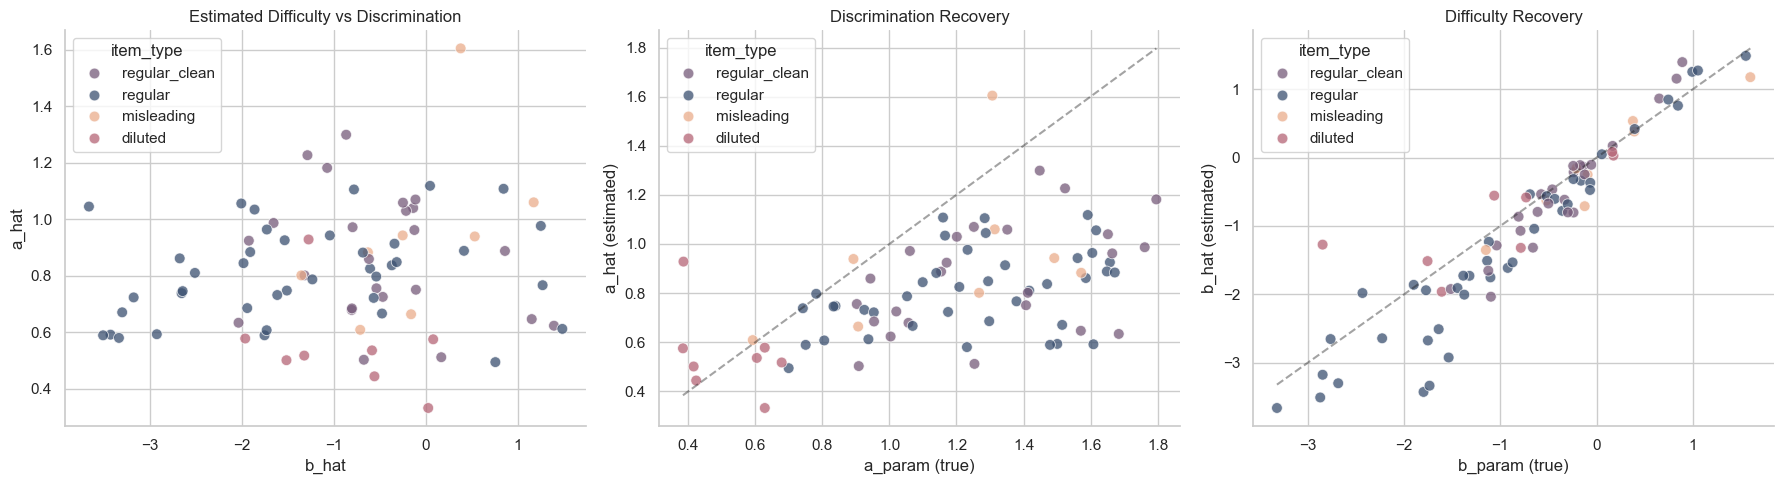

In [13]:
print("Difficulty (b) summary:")
print(item_analysis_ctt_irt["b_hat"].describe(), "\n")

print("Discrimination (a) summary:")
print(item_analysis_ctt_irt["a_hat"].describe(), "\n")


fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- Panel 1: b_hat vs a_hat ---
sns.scatterplot(
    data=item_analysis_ctt_irt,
    x="b_hat",
    y="a_hat",
    hue="item_type",
    palette=item_type_colors,
    s=60,
    alpha=0.75,
    ax=axes[0]
)
axes[0].set_title("Estimated Difficulty vs Discrimination")
axes[0].set_xlabel("b_hat")
axes[0].set_ylabel("a_hat")

# --- Panel 2: a_hat vs a_param ---
sns.scatterplot(
    data=item_analysis_ctt_irt,
    x="a_param",
    y="a_hat",
    hue="item_type",
    palette=item_type_colors,
    s=60,
    alpha=0.75,
    ax=axes[1]
)
axes[1].plot([item_analysis_ctt_irt.a_param.min(), item_analysis_ctt_irt.a_param.max()],
             [item_analysis_ctt_irt.a_param.min(), item_analysis_ctt_irt.a_param.max()],
             "k--", alpha=0.4)
axes[1].set_title("Discrimination Recovery")
axes[1].set_xlabel("a_param (true)")
axes[1].set_ylabel("a_hat (estimated)")

# --- Panel 3: b_hat vs b_param ---
sns.scatterplot(
    data=item_analysis_ctt_irt,
    x="b_param",
    y="b_hat",
    hue="item_type",
    palette=item_type_colors,
    s=60,
    alpha=0.75,
    ax=axes[2]
)
axes[2].plot([item_analysis_ctt_irt.b_param.min(), item_analysis_ctt_irt.b_param.max()],
             [item_analysis_ctt_irt.b_param.min(), item_analysis_ctt_irt.b_param.max()],
             "k--", alpha=0.4)
axes[2].set_title("Difficulty Recovery")
axes[2].set_xlabel("b_param (true)")
axes[2].set_ylabel("b_hat (estimated)")

# Clean up
for ax in axes:
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

### Comparing Generating and Estimated IRT Parameters

The dataset used in this notebook was created by simulating item responses from a
known set of IRT parameters (a_param, b_param). These values represent the
*generating* item characteristics: the discrimination and difficulty that define
the “true” response process in the simulated population.

In the next step, we fit a Bayesian 2PL IRT model to the simulated data. This
model estimates its own set of item parameters (a_hat, b_hat) based solely on
the observed responses. Because the estimation model uses different priors,
identification constraints, and numerical properties than the simulation
procedure, the recovered parameters will not match the generating values
exactly.

This comparison is therefore not a test of whether the model reproduces the
exact numeric values, but whether it recovers the *structure* of the items:
their relative ordering, their separation by item type, and the overall shape
of the parameter space. Good recovery means that items with higher true
difficulty also have higher estimated difficulty, and similarly for
discrimination, even if the absolute values differ.

The following plot visualizes this relationship by showing the generating
parameters (circles) and the estimated parameters (crosses), with arrows
indicating the shift from true to estimated values.

### Why true and estimated parameters differ

The estimated IRT parameters do not match the generating parameters exactly,
and this is expected for several reasons:

1. **Person parameters introduce stochastic variation.**  
   Item estimates depend on the distribution of θ, so even with perfect model
   fit the recovered parameters will deviate from the generating values.

2. **The simulation model and the estimation model are not identical.**  
   The data were generated using our own simulation logic, whereas the
   estimation uses a Bayesian 2PL model with different priors and
   identification constraints. Differences between true and estimated values
   therefore reflect model structure rather than error.

3. **Bayesian priors induce shrinkage.**  
   Extreme discrimination or difficulty values are regularized toward the
   center of the prior distribution, which improves stability but reduces
   exact recovery.

4. **IRT parameters are identifiable only up to a linear transformation.**  
   The absolute scale of (a, b, θ) is arbitrary; only their relative structure
   matters. Good recovery therefore means preserving the ordering and
   relationships, not reproducing exact numeric values.

Overall, the model performs well when the estimated parameters preserve the
relative ordering and item-type structure of the generating parameters, even
if the absolute values differ.

## CTT–IRT (recovered) Comparison

This section compares empirical CTT statistics with the estimated IRT parameters.
Whereas CTT difficulty and discrimination are sample‑dependent descriptive indices,
IRT parameters (a, b) represent model‑based latent item characteristics.

Comparing both perspectives allows us to evaluate:

- how well empirical difficulty (proportion correct) aligns with IRT difficulty (b)
- how well empirical discrimination (item–total correlation) aligns with IRT discrimination (a)

Together, these diagnostics provide a comprehensive view of item functioning across
both classical and modern test theory.

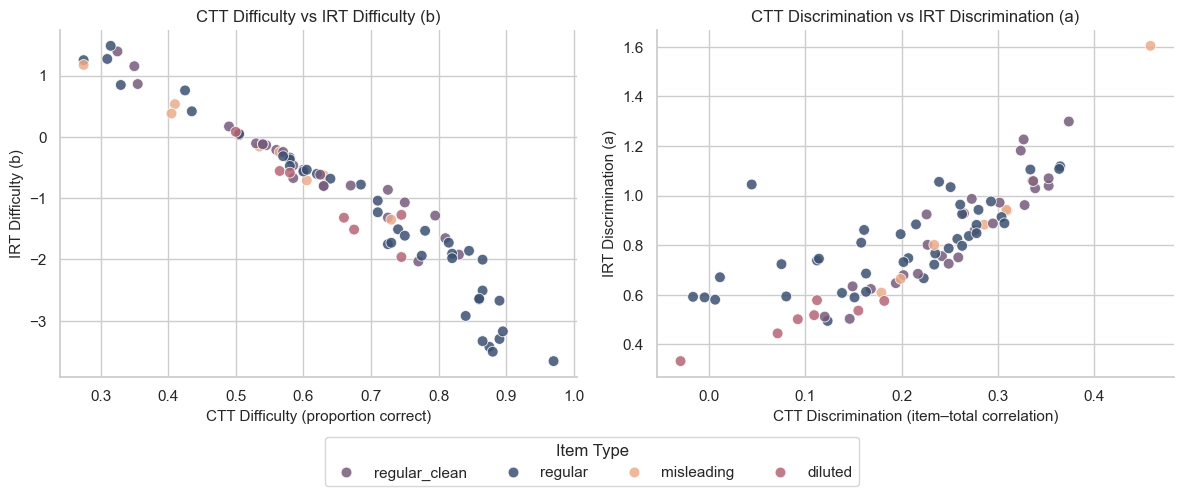

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=False)

# 1. CTT Difficulty vs IRT Difficulty (b)
ax = axes[0]
sns.scatterplot(
    data=item_analysis_ctt_irt,
    x="difficulty",
    y="b_hat",
    hue="item_type",
    palette=item_type_colors,
    s=60,
    alpha=0.85,
    ax=ax
)

ax.set_title("CTT Difficulty vs IRT Difficulty (b)", fontsize=12)
ax.set_xlabel("CTT Difficulty (proportion correct)", fontsize=11)
ax.set_ylabel("IRT Difficulty (b)", fontsize=11)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# 2. CTT Discrimination vs IRT Discrimination (a)
ax = axes[1]
sns.scatterplot(
    data=item_analysis_ctt_irt,
    x="discrimination",
    y="a_hat",
    hue="item_type",
    palette=item_type_colors,
    s=60,
    alpha=0.85,
    ax=ax
)

ax.set_title("CTT Discrimination vs IRT Discrimination (a)", fontsize=12)
ax.set_xlabel("CTT Discrimination (item–total correlation)", fontsize=11)
ax.set_ylabel("IRT Discrimination (a)", fontsize=11)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# ---------------------------------------------------------
# Legend (nur einmal, zentriert unter den Plots)
handles, labels = axes[1].get_legend_handles_labels()
fig.legend(handles, labels, title="Item Type", loc="lower center", ncol=4)
axes[1].get_legend().remove()
axes[0].get_legend().remove()

plt.tight_layout(rect=[0, 0.1, 1, 1])
plt.show()

## Person‑Level Diagnostics

This section documents and checks person-level (testtaker-level) structure.

We analyze relationships between:

- `theta_true`: generating latent ability (ground truth from the simulation)
- `theta_post`: posterior mean ability estimate from the Bayesian 2PL model
- behavioral traits: `carelessness`, `guessiness`, `testwiseness`
- observed performance: `score`, `score_pct`

These diagnostics serve two purposes:

1. **Sanity check**: the simulated traits should show interpretable associations with performance.
2. **Model recovery**: `theta_post` should be strongly associated with `theta_true` (up to estimation error).

Note: correlations involving `score` / `score_pct` are expected to be strong because these are derived from the same response data used to estimate `theta_post`.

In [15]:
# recovered ability
testtakers_post_analysis["theta_post"] = idata.posterior["theta"].mean(dim=("chain", "draw")).values

Correlations


,theta_true,theta_post,carelessness,guessiness,testwiseness,score,score_pct
theta_true,1.000,0.897,-0.126,0.007,0.454,0.857,0.857
theta_post,0.897,1.000,-0.191,0.007,0.452,0.986,0.986
carelessness,-0.126,-0.191,1.000,0.005,-0.109,-0.187,-0.187
guessiness,0.007,0.007,0.005,1.000,-0.049,0.014,0.014
testwiseness,0.454,0.452,-0.109,-0.049,1.000,0.466,0.466
score,0.857,0.986,-0.187,0.014,0.466,1.000,1.000
score_pct,0.857,0.986,-0.187,0.014,0.466,1.000,1.000


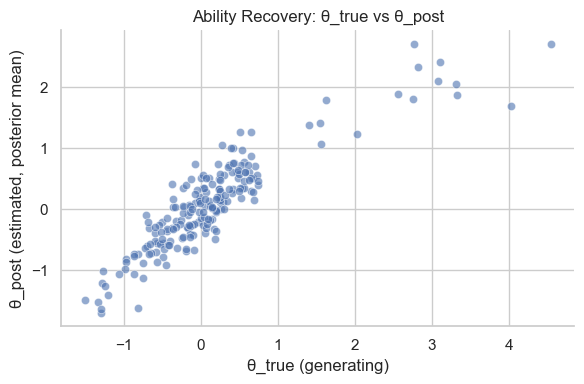

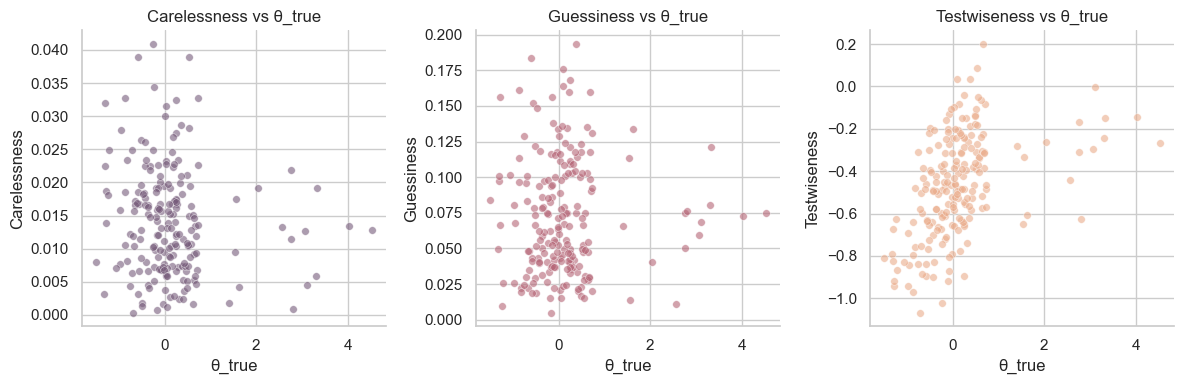

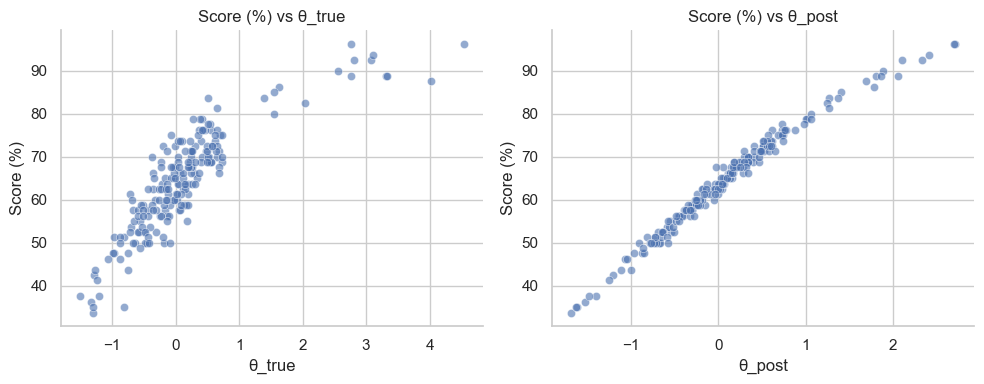

In [16]:
# Person-level plots + correlations

# Ensure theta_post is present (computed earlier)
if "theta_post" not in testtakers_post_analysis.columns:
    raise ValueError("Column `theta_post` missing. Run the Bayesian 2PL IRT model cells first.")

cols = [
    "theta_true",
    "theta_post",
    "carelessness",
    "guessiness",
    "testwiseness",
    "score",
    "score_pct",
]

corr = testtakers_post_analysis[cols].corr(numeric_only=True)
print("Correlations")
display(corr.round(3))

# --- Theta recovery: theta_true vs theta_post ---
plt.figure(figsize=(6, 4))
ax = sns.scatterplot(
    data=testtakers_post_analysis,
    x="theta_true",
    y="theta_post",
    s=35,
    alpha=0.6,
    color="#4C72B0",
)
ax.set_title("Ability Recovery: θ_true vs θ_post")
ax.set_xlabel("θ_true (generating)")
ax.set_ylabel("θ_post (estimated, posterior mean)")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()

# --- Traits vs ability / performance ---
fig, axes = plt.subplots(1, 3, figsize=(12, 4), sharey=False)

sns.scatterplot(
    data=testtakers_post_analysis,
    x="theta_true",
    y="carelessness",
    s=30,
    alpha=0.6,
    color="#765B7A",
    ax=axes[0],
)
axes[0].set_title("Carelessness vs θ_true")
axes[0].set_xlabel("θ_true")
axes[0].set_ylabel("Carelessness")

sns.scatterplot(
    data=testtakers_post_analysis,
    x="theta_true",
    y="guessiness",
    s=30,
    alpha=0.6,
    color="#B56576",
    ax=axes[1],
)
axes[1].set_title("Guessiness vs θ_true")
axes[1].set_xlabel("θ_true")
axes[1].set_ylabel("Guessiness")

sns.scatterplot(
    data=testtakers_post_analysis,
    x="theta_true",
    y="testwiseness",
    s=30,
    alpha=0.6,
    color="#eaac8b",
    ax=axes[2],
)
axes[2].set_title("Testwiseness vs θ_true")
axes[2].set_xlabel("θ_true")
axes[2].set_ylabel("Testwiseness")

for ax in axes:
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

# --- Performance vs ability ---
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

sns.scatterplot(
    data=testtakers_post_analysis,
    x="theta_true",
    y="score_pct",
    s=35,
    alpha=0.6,
    color="#4C72B0",
    ax=axes[0],
)
axes[0].set_title("Score (%) vs θ_true")
axes[0].set_xlabel("θ_true")
axes[0].set_ylabel("Score (%)")
axes[0].spines["top"].set_visible(False)
axes[0].spines["right"].set_visible(False)

sns.scatterplot(
    data=testtakers_post_analysis,
    x="theta_post",
    y="score_pct",
    s=35,
    alpha=0.6,
    color="#4C72B0",
    ax=axes[1],
)
axes[1].set_title("Score (%) vs θ_post")
axes[1].set_xlabel("θ_post")
axes[1].set_ylabel("Score (%)")
axes[1].spines["top"].set_visible(False)
axes[1].spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

## Save the dataframes

In [17]:
testtakers_post_analysis.to_csv(ANALYSIS_DIR/"testtakers_post_analysis_py.csv", index=False)
testtakers_post_analysis.to_pickle(ANALYSIS_DIR/"testtakers_post_analysis.pkl")

In [18]:
item_analysis_ctt_irt.to_csv(ANALYSIS_DIR/"item_analysis_py.csv", index=False)
item_analysis_ctt_irt.to_pickle(ANALYSIS_DIR/"item_analysis.pkl")

# **Item‑Level Diagnostics**

To understand how each item behaves across different levels of performance and ability, we generate a **six‑panel diagnostic grid**. This visualization integrates classical test theory (CTT) and item response theory (IRT), showing how response patterns relate to both observed scores and model‑based ability estimates.

The six panels provide complementary perspectives:

---

**1. IRT Item Map (a–b space)**  
Positions the item relative to all others in terms of:

- **difficulty** (b‑parameter)  
- **discrimination** (a‑parameter)  
- **item type**

This situates the item within the broader structure of the test and highlights whether it behaves similarly to other items of the same type.

---

**2. CTT Item Map (difficulty vs. discrimination)**  
Displays the item’s classical difficulty (p‑value) and discrimination (corrected item–total correlation) in the same way.  
This provides a familiar, score‑based view of item functioning and allows quick comparison with the rest of the test.

---

**3. IRT Item Characteristic Curve (ICC)**  
Shows the model‑based probability of a correct response as a function of latent ability \( \theta \).  
A tangent line at \( \theta = b \) visualizes the item’s discrimination (slope), and the b‑parameter is marked explicitly.  
This panel isolates the item’s psychometric behavior from total‑score circularity.

---

**4. Answer Distribution by Score Group**  
Displays how often each answer option is selected within score‑percentage groups.  
Because these groups are derived from the total score, this panel reflects a **circular relationship**:  
items that contribute strongly to the score naturally show clearer separation between groups.

Useful for:

- distractor analysis  
- identifying non‑functioning or overly attractive distractors  
- spotting score‑group inconsistencies

---

**5. Item Summary Block**  
A compact textual summary of key item statistics:

- CTT difficulty  
- CTT discrimination  
- IRT a‑parameter  
- IRT b‑parameter  
- item type  

This provides a quick reference for reviewers.

---

**6. CTT Discrimination Plot**  
Shows the relationship between:

- **item score** (0/1)  
- **total score excluding the item**

The red dashed line connects the **group means** for incorrect vs. correct responders, and the corrected item–total correlation is displayed.  
This panel visualizes how strongly the item separates low‑ and high‑scoring examinees.

---

 **Integrated Interpretation**

Together, these six panels provide a comprehensive view of item behaviour:

- how distractors function across performance levels  
- how well the ICC fits empirical response patterns  
- how strongly the item discriminates between ability groups  
- whether score‑based and ability‑based patterns diverge  
- how the item compares to the rest of the test in both CTT and IRT space  

This integrated view helps identify items that are misfitting, poorly discriminating, too easy or too hard, or inconsistent across scoring and ability metrics.
"""

from IPython.display import Markdown, display
display(Markdown(markdown_text))

In [19]:
item_analysis_ctt_irt

,item,item_type,num_options,correct_answer,a_param,b_param,slip,distractors,distractor_weights,difficulty,discrimination,a_hat,b_hat
0,item1,regular_clean,4,A,1.003326,0.889566,0.019005,"[B, C, D]","{'B': 0.45, 'C': 0.3, 'D': 0.25000000000000006}",0.325,0.168,0.622920,1.395537
1,item2,regular_clean,5,D,1.448345,-0.810366,0.004695,"[A, B, C, E]","{'A': 0.45, 'B': 0.3, 'C': 0.12500000000000003...",0.725,0.374,1.298684,-0.863803
2,item3,regular_clean,5,D,1.651941,-0.140658,0.021120,"[A, B, C, E]","{'A': 0.45, 'B': 0.3, 'C': 0.12500000000000003...",0.545,0.353,1.039475,-0.134784
3,item4,regular,5,A,0.937108,1.549212,0.107733,"[B, C, D, E]","{'B': 0.45, 'C': 0.3, 'D': 0.12500000000000003...",0.315,0.163,0.611691,1.486731
4,item5,misleading,4,D,0.892433,0.376604,0.083355,"[A, B, C]","{'A': 0.65625, 'B': 0.18749999999999997, 'C': ...",0.410,0.310,0.938751,0.534466
...,...,...,...,...,...,...,...,...,...,...,...,...,...
75,item76,regular,5,C,1.099112,-2.431094,0.072278,"[A, B, D, E]","{'A': 0.5217391304347826, 'B': 0.2608695652173...",0.820,0.199,0.844235,-1.980016
76,item77,regular,4,A,0.833079,-2.226736,0.005027,"[B, C, D]","{'B': 0.45, 'C': 0.3, 'D': 0.25000000000000006}",0.860,0.114,0.745235,-2.641735
77,item78,regular,3,C,1.616659,-1.373761,0.020109,"[A, B]","{'A': 0.6, 'B': 0.4}",0.865,0.239,1.055366,-2.003945
78,item79,diluted,4,C,0.603983,-0.732294,0.051830,"[A, B, D]","{'A': 0.34615384615384615, 'B': 0.461538461538...",0.580,0.155,0.535581,-0.582759


In [20]:
plot_df = answer_matrix.copy()
plot_df['score']= testtakers_post_analysis['score_pct']
plot_df

def irt_prob(theta, a, b):
    theta = np.array(theta)
    return 1 / (1 + np.exp(-a * (theta - b)))
    
def plot_item_descriptive_grid(
    item_analysis,
    plot_df,
    binary,
    item_col,
    save=False,
    save_dir="../figures/item_panels",
    dpi=200,
):

    meta = item_analysis_ctt_irt[item_analysis_ctt_irt["item"] == item_col].squeeze()
    correct_answer = meta["correct_answer"]
    distractors = meta["distractors"]
    a = float(meta["a_hat"])
    b = float(meta["b_hat"])
    item_type = meta["item_type"]

    df = plot_df.copy()
    df["score"] = df["score"] / 100

    bins = [0, 0.60, 0.70, 0.80, 0.90, 1.01]
    labels = ["0–59%", "60–69%", "70–79%", "80–89%", "90–100%"]
    
    df["score_pct_group"] = pd.cut(df["score"], bins=bins, labels=labels, include_lowest=True)

    tmp = df[["score_pct_group", item_col]].rename(columns={item_col: "selected_answer"})

    prop = (
        tmp.groupby(["score_pct_group", "selected_answer"], observed=False)
        .size()
        .to_frame("count")
        .assign(
            proportion=lambda d: d["count"] /
            d.groupby(level=0, observed=False)["count"].transform("sum")
        )
        .reset_index()
    )

    all_answers = [correct_answer] + distractors
    
    for grp in labels:
        for ans in all_answers:
            if not ((prop["score_pct_group"] == grp) & (prop["selected_answer"] == ans)).any():
                prop = pd.concat([
                    prop,
                    pd.DataFrame({
                        "score_pct_group": [grp],
                        "selected_answer": [ans],
                        "count": [0],
                        "proportion": [0],
                    })
                ])

    pivot_df = prop.pivot(index="score_pct_group", columns="selected_answer", values="proportion")
    pivot_df = pivot_df[[correct_answer] + [c for c in pivot_df.columns if c != correct_answer]]

    group_sizes = tmp.groupby("score_pct_group", observed=True).size()
    # Ensure all groups exist
    group_sizes = tmp.groupby("score_pct_group", observed=True).size().reindex(labels, fill_value=0)
    max_size = group_sizes.max()
    if max_size == 0:
        widths = pd.Series(1.0, index=labels)   # fallback if dataset is empty
    else:
        widths = group_sizes / max_size




    # Create 3×2 grid
    fig, axes = plt.subplots(3, 2, figsize=(14, 12))
    plt.subplots_adjust(hspace=0.40, wspace=0.3)


    # ROW 1 — CTT + IRT maps
    # --- Panel 1: IRT map
    ax = axes[0, 0]
    sns.scatterplot(
        data=item_analysis_ctt_irt,
        x="a_hat",
        y="b_hat",
        hue="item_type",
        palette=item_type_colors,
        alpha=0.8,
        s=40,
        ax=ax,
    )
    sns.scatterplot(
        data=item_analysis_ctt_irt[item_analysis_ctt_irt.item == item_col],
        x="a_hat",
        y="b_hat",
        color=item_type_colors[item_type],
        edgecolor="black",
        s=100,
        ax=ax,
    )
    ax.set_title("IRT item map")
    ax.grid(alpha=0.2)
    ax.legend([], [], frameon=False)

       # --- Panel 2: CTT map
    ax = axes[0, 1]
    sns.scatterplot(
        data=item_analysis_ctt_irt,
        x="discrimination",
        y="difficulty",
        hue="item_type",
        palette=item_type_colors,
        alpha=0.8,
        s=40,
        ax=ax,
    )
    sns.scatterplot(
        data=item_analysis_ctt_irt[item_analysis_ctt_irt.item == item_col],
        x="discrimination",
        y="difficulty",
        color=item_type_colors[item_type],
        edgecolor="black",
        s=100,
        ax=ax,
    )
    ax.set_title("CTT item map")
    ax.grid(alpha=0.2)
    #ax.legend([], [], frameon=False)
    ax.legend(
        title="Item Type", 
        bbox_to_anchor=(1.02, 1), 
        loc="upper left", 
        frameon=False
    )

    
    # ROW 2 — ICC curve + distractor countplot
    # --- Panel 3: ICC curve
    ax = axes[1, 0]
    
    theta_range = np.linspace(-6, 6, 800)
    p_curve = irt_prob(theta_range, a, b)
    
    ax.plot(theta_range, p_curve, color="black", linewidth=1.2)
    
    # Mark b-parameter
    ax.axvline(b, color="grey", linestyle="--", linewidth=1)
    ax.text(b, 
            0.02, 
            f"b = {b:.2f}",
            ha="center",
            va="bottom", 
            fontsize=9, 
            rotation=90
           )
    
    # Discrimination tangent
    slope = a / 4
    theta_tan = np.linspace(b - 1, b + 1, 200)
    p_tan = 0.5 + slope * (theta_tan - b)
    ax.plot(theta_tan, 
            p_tan,
            color="#297045", 
            linestyle=":", 
            linewidth=3,
            label=f"Tangent (slope ≈ {slope:.2f})"
    )
    
    ax.set_title(f"IRT curve for {item_col}")
    ax.set_xlabel(r"Ability $\theta$")
    ax.set_ylabel("P(correct)")
    ax.grid(alpha=0.2)
    ax.legend(loc="lower right", fontsize=9, frameon=False)


     # --- Panel: Answer distribution (uniform-width bars)
    ax = axes[1, 1]
    colors = get_colors(correct_answer)
    
    # Standard stacked bar chart with equal-width bars
    pivot_df.plot(
        kind="bar",
        stacked=True,
        color=[colors[c] for c in pivot_df.columns],
        ax=ax,
        width=0.8,   # uniform width
    )
    
    # Mean line
    item_mean = df[item_col].eq(correct_answer).mean()
    ax.axhline(item_mean, color="black", linestyle="--", linewidth=1.2)
    ax.text(
        0.98,
        item_mean + 0.02,
        f"Mean = {item_mean:.2f}",
        transform=ax.get_yaxis_transform(),
        ha="right",
        fontsize=9,
    )
    
    # Clean x-axis labels
    ax.set_xticklabels(pivot_df.index, rotation=0)
    ax.set_xlabel("Score percentage group")
    ax.set_ylabel("Proportion of selected answers")
    ax.set_title(f"Answer distribution for {item_col} (Correct: {correct_answer})")
    ax.set(ylim=(0, 1.04))

    # Add group sizes under each bar
    for i, grp in enumerate(pivot_df.index):
        n = group_sizes.loc[grp]
        ax.text(
            i,
            1.01,
            f"n={n}",
            ha="center",
            va="top",
            fontsize=10,
            transform=ax.get_xaxis_transform(),
        )
    
    ax.legend(
        title="Answer choice", 
        bbox_to_anchor=(1.02, 1), 
        loc="upper left", 
        frameon=False
    )
    ax.grid(alpha=0.2)

    # --- Panel 5: BRV summary
    ax = axes[2, 0]
    ax.axis("off")
    text = (
        f"Item: {item_col}\n\n"
        f"IRT a_hat:         {meta['a_hat']:.3f}\n"
        f"IRT b_hat:         {meta['b_hat']:.3f}\n\n"        
        f"Difficulty (p):    {meta['difficulty']:.3f}\n"
        f"Discrimination:    {meta['discrimination']:.3f}\n"

    )
    ax.text(0.02, 0.98, text, ha="left", va="top", fontsize=11, family="monospace")

   # --- Panel 5:6 CTT discrimination plot ---
    ax = axes[2, 1]
    
    x = binary[item_col]
    
    # total score excluding the item
    total_excl = binary.drop(columns=[item_col]).sum(axis=1)
    
    # corrected item–total correlation
    discr = np.corrcoef(x, total_excl)[0, 1]
    
    # jitter
    jitter = (np.random.rand(len(x)) - 0.5) * 0.1
    
    # scatter
    ax.scatter(x + jitter, total_excl, alpha=0.3, s=20, color="gray")
    
    # group means
    means = total_excl.groupby(x).mean()
    ax.scatter([0, 1], means, color="#297045", s=120, zorder=5)
    ax.plot([0, 1], means, color="#297045", linewidth=2, linestyle="dashed")
    
    # Midpoint of the discimination line
    mid_x = 0.5
    mid_y = (means.loc[0] + means.loc[1]) / 2
    offset = (total_excl.max() - total_excl.min()) * 0.03

    # labels
    ax.set_xticks([0, 1])
    ax.set_xticklabels(["Incorrect", "Correct"])
    ax.set_xlabel("Item Score")
    ax.set_ylabel("Total Score (excluding item)")
    ax.set_title(f"CTT Discrimination for {item_col}")
    
    # annotation
    ax.text(
        mid_x,
        mid_y + offset,  
        f"Corrected item–total \ncorrelation = {discr:.3f}",
        ha="center",
        va="bottom",
        fontsize=11,
        bbox=dict(facecolor="white", alpha=0.7, edgecolor="none"),
    )

    # Clean up
    for ax in axes.flatten():
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

    return fig


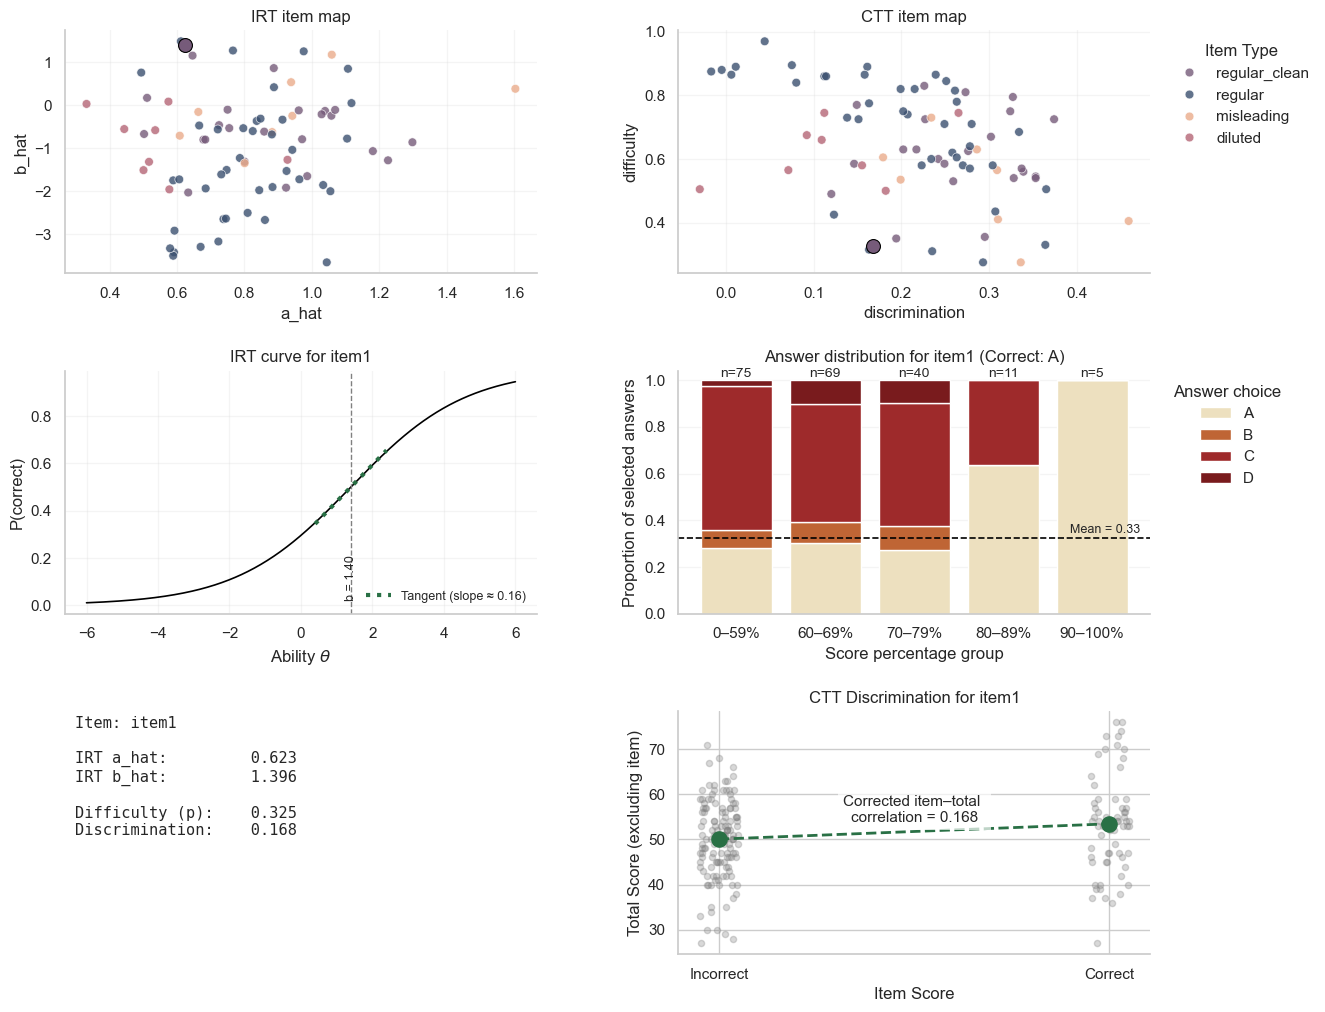

In [21]:
# Example plot
_ = plot_item_descriptive_grid(item_analysis_ctt_irt, plot_df, binary, 'item1')

### Exporting Item-Level Diagnostic Plots

For transparency and reproducibility, we generate a full diagnostic plot for
each item and store the resulting figures in a dedicated folder. This creates a
complete item-level documentation set, allowing reviewers and collaborators to
inspect distractor functioning, score-based and ability-based performance
patterns, and the alignment between empirical data and the estimated IRT model.


In [22]:
def save_item_figure(fig, base_dir, item, item_type, suffix=""):
    """Save a figure into the correct item-type subfolder."""
    type_dir = os.path.join(base_dir, item_type)
    os.makedirs(type_dir, exist_ok=True)

    filename = f"{item}{suffix}.png"
    filepath = os.path.join(type_dir, filename)

    fig.savefig(filepath, dpi=150, bbox_inches="tight")
    plt.close(fig)


In [23]:
# Generate and save all item-level plots (panel + descriptive grid)
for item in item_analysis["item"]:
    item_type = item_analysis.loc[item_analysis["item"] == item, "item_type"].values[0]

    # Panel plot
    fig_panel = plot_item_descriptive_grid(item_analysis_ctt_irt, plot_df, binary, item)
    save_item_figure(fig_panel, BASE_DIR, item, item_type, suffix="_panel_py")


print("All item plots generated and saved.")


All item plots generated and saved.
